# Prompt: 
Using data from: spambase, build a Naive Bayes email classifier. Nothing too fancy, just a training module, and a classifier module. Submit code and accuracy you get on the spambase dataset.

# 🧠 Step 1: Understanding the Problem: 
In plain English: "Given the words/features in this email, what's the probability it's spam?"

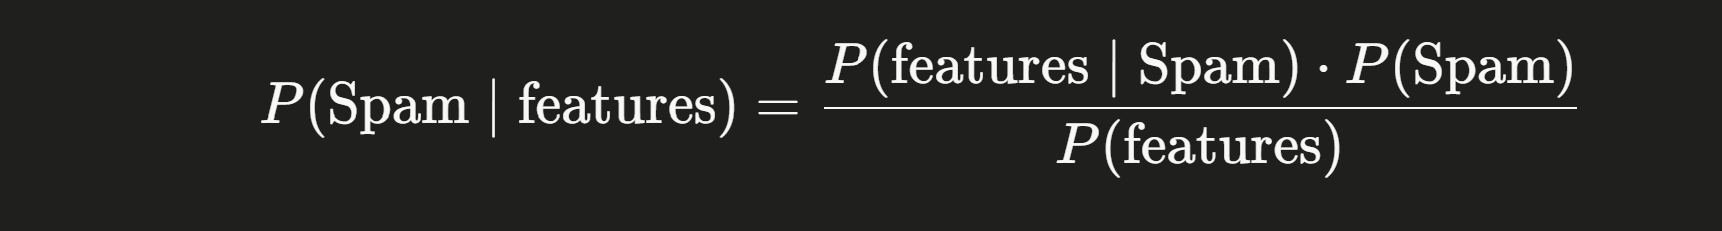

Why Gaussian Naive Bayes for Spambase?
The Spambase dataset gives us continuous features (word frequencies as percentages, character frequencies, run-length statistics). 

# Set Up and Data Ingestion
This handles our dependencies and pulls the raw matrix (spambase.data) into the environment. We separate the matrix into X (our 57 features) and y (our target label, where 1 is spam and 0 is not).

In [ ]:
import numpy as np
import pandas as pd

#Load the Spambase dataset directly into pandas DataFrame
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/spambase/spambase.data"

data = pd.read_csv(url, header=None).values

# Separate features and labels
X = data[:, :-1]  # All columns except the last one are features
y = data[:, -1]   # The last column is the label

print(f"Dataset loaded with {X.shape[0]} samples and {X.shape[1]} features.")


Dataset loaded with 4601 samples and 57 features.
Dataset loaded. Features shape: (4601, 57), Target shape: (4601,)


# The Train/Test Split
Algorithms need to be tested on data they have never seen before; otherwise, you are just testing its memory, not its predictive power.

In [ ]:
# import train_test_split from scikit-learn 
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

Training set: 3680 samples
Testing set: 921 samples


# Importing and Training the model
We import the specific Naive Bayes algorithm designed for continuous features (GaussianNB). We instantiate it and immediately call .fit() passing in our training data. The library calculates all the means, variances, and prior probabilities


In [5]:
from sklearn.naive_bayes import GaussianNB

#instantiate the Gaussian Naive Bayes classifier
model = GaussianNB()

# Fit the model to the training data
model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


# Prediction and Evaluation
We use the trained model to classify the unseen testing data. Then, we import accuracy_score to compare the model's predictions against the actual answers (y_test).

In [6]:
from sklearn.metrics import accuracy_score, classification_report

# Ask the model to predict the classess for the test features
predictions = model.predict(X_test)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy with scikit-learn's GaussianNB: {accuracy * 100:.2f}%\n")

# Print a detailed classification report
print("Classification Report:")
print(classification_report(y_test, predictions, target_names=["Not Spam", "Spam"]))


Accuracy with scikit-learn's GaussianNB: 82.08%

Classification Report:
              precision    recall  f1-score   support

    Not Spam       0.95      0.73      0.82       531
        Spam       0.72      0.95      0.82       390

    accuracy                           0.82       921
   macro avg       0.83      0.84      0.82       921
weighted avg       0.85      0.82      0.82       921



# Extra Credit (Peeking Inside the "Black Box.)
 scikit-learn stores the mathematical profiles it built during training in special variables ending with an underscore (like theta_ for the mean and var_ for variance). This cell extracts those values to show exactly what the model learned about the "Spam" class versus the "Not Spam" class.

In [10]:
# Extract the calculated prior probabilities P(Class)
# GaussianNB stores these directly as raw probabilities!
priors = model.class_prior_
print(f"Learned Prior Probability of Not Spam: {priors[0] * 100:.1f}%")
print(f"Learned Prior Probability of Spam: {priors[1] * 100:.1f}%\n")

# Extract the mean (theta_) and variance (var_) for the first 5 features
# Note: model.classes_[0] is Not Spam, model.classes_[1] is Spam
print("Sample of the learned statistics for the first 5 features:\n")

for feature_idx in range(5):
    print(f"Feature {feature_idx}:")
    print(f"  Not Spam -> Mean: {model.theta_[0][feature_idx]:.4f}, Variance: {model.var_[0][feature_idx]:.4f}")
    print(f"  Spam     -> Mean: {model.theta_[1][feature_idx]:.4f}, Variance: {model.var_[1][feature_idx]:.4f}")
    print("-" * 40)

Learned Prior Probability of Not Spam: 61.3%
Learned Prior Probability of Spam: 38.7%

Sample of the learned statistics for the first 5 features:

Feature 0:
  Not Spam -> Mean: 0.0707, Variance: 0.0835
  Spam     -> Mean: 0.1501, Variance: 0.0930
----------------------------------------
Feature 1:
  Not Spam -> Mean: 0.2236, Variance: 2.4489
  Spam     -> Mean: 0.1704, Variance: 0.1368
----------------------------------------
Feature 2:
  Not Spam -> Mean: 0.2002, Variance: 0.2574
  Spam     -> Mean: 0.4052, Variance: 0.2330
----------------------------------------
Feature 3:
  Not Spam -> Mean: 0.0007, Variance: 0.0005
  Spam     -> Mean: 0.1424, Variance: 4.0380
----------------------------------------
Feature 4:
  Not Spam -> Mean: 0.1787, Variance: 0.3809
  Spam     -> Mean: 0.5065, Variance: 0.5078
----------------------------------------
